# Proyek AMBA: Pemodelan Machine Learning & Evaluasi Risiko Suspensi

Dokumen rujukan:
- `AMBA-kamus-variabel.md` (Bagian 4: Variabel Keluaran & Bagian 5: Variabel Evaluasi)
- Dataset input: `output/dataset_modeling_ambang.csv`

## Sasaran Notebook
1. **Baseline Model**: Membangun model klasifikasi awal menggunakan **Logistic Regression** terstandardisasi.
2. **Penanganan Imbalance Class**: Mengimplementasikan pembobotan kelas (`class_weight='balanced'`) pada Logistic Regression untuk meningkatkan *recall* pada kelas minoritas (kejadian suspensi/risiko).
3. **Model Non-Linear (Random Forest)**: Membangun **Random Forest Classifier** dengan penanganan *imbalance class* untuk menangkap interaksi non-linear antar indikator fundamental dan likuiditas.
4. **Evaluasi & Perbandingan Komprehensif**: Menilai performa model menggunakan 5-Fold Stratified Cross Validation dengan metrik: ROC-AUC, Precision, Recall, F1-Score, Confusion Matrix, dan ROC Curves.
5. **Generasi Skor & Peringkat Pasar (Section 4 Kamus Variabel)**:
   - Menghasilkan variabel keluaran AMBA: `skor`, `persentil` (0-100), `kategori` (Rendah/Sedang/Tinggi/Sangat Tinggi), tren `arah_30h`, `status` (`dinilai`/`sudah_ditandai`), serta atribusi `indikator_dominan` dan `kontribusi`.
   - Ekspor artefak resmi ke `output/scores.json` dan `output/backtest.json`.

In [1]:
# 1. Inisialisasi Environment & Import Library
import os
import sys
import json
import warnings
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score
)

# Robust project root determination
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, "output", "dataset_modeling_ambang.csv")):
    project_root = cwd
elif os.path.exists(os.path.join(cwd, "..", "..", "output", "dataset_modeling_ambang.csv")):
    project_root = os.path.abspath(os.path.join(cwd, "..", ".."))
elif os.path.exists(os.path.join(cwd, "..", "output", "dataset_modeling_ambang.csv")):
    project_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    project_root = os.path.abspath(os.path.join(cwd, "..", ".."))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Environment siap. Project root:", project_root)

Environment siap. Project root: C:\Users\Yosua Triantara\Documents\Project\Ambang


In [2]:
# 2. Memuat Dataset Modeling AMBA
dataset_path = os.path.join(project_root, "output", "dataset_modeling_ambang.csv")
df = pd.read_csv(dataset_path)

print(f"Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom")
print("Daftar sampel emiten:")
print(df[["symbol", "as_of_date", "board", "is_event_90d", "event_category", "already_flagged"]].head(10))

Dataset berhasil dimuat: 114 baris x 37 kolom
Daftar sampel emiten:
    symbol  as_of_date         board  is_event_90d event_category  \
0  BBCA.JK  2026-07-15          Main             0            NaN   
1  TLKM.JK  2026-07-15          Main             0            NaN   
2  ASII.JK  2026-07-15          Main             0            NaN   
3  AMMN.JK  2026-07-15          Main             0            NaN   
4  IMPC.JK  2026-07-15          Main             0            NaN   
5  AADI.JK  2026-07-15          Main             0            NaN   
6  MGLV.JK  2026-07-15  Acceleration             0              A   
7  SOHO.JK  2026-07-15   Development             0            NaN   
8  BELI.JK  2026-07-15   New Economy             0            NaN   
9  SRAJ.JK  2026-07-15          Main             0            NaN   

   already_flagged  
0                0  
1                0  
2                0  
3                0  
4                0  
5                0  
6                0  
7   

In [3]:
# 3. Seleksi Fitur dan Definisi Target Prediksi
# 11 Indikator Risiko Turunan (Bagian 3 Kamus Variabel):
feature_cols = [
    "lapor_jarak_hari",
    "lapor_terlambat",
    "tanpa_pendapatan",
    "ekuitas_negatif",
    "utang_terhadap_aset",
    "ako_negatif_berturut",
    "hari_tanpa_transaksi_90d",
    "rasio_volume_30_90",
    "hari_di_batas_bawah_90d",
    "turun_dari_puncak_90d",
    "volatilitas_90d"
]

X = df[feature_cols].copy()
# Imputasi nilai missing dengan nilai median
X = X.fillna(X.median())

# Target Klasifikasi:
# Kejadian suspensi / risiko material bursa dalam jendela 90 hari ke depan
y = df["event_category"].notna().astype(int)

class_counts = y.value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]

print("=== Fitur Masukan Model (X) ===")
print(feature_cols)
print(f"\nDimensi X: {X.shape}")
print(f"\nDistribusi Target (y):")
print(f"  Kelas 0 (Tidak Ada Suspensi) : {class_counts[0]} ({class_counts[0]/len(y)*100:.1f}%)")
print(f"  Kelas 1 (Ada Suspensi 90 Hari): {class_counts[1]} ({class_counts[1]/len(y)*100:.1f}%)")
print(f"  Rasio Ketimpangan (Imbalance): 1 : {imbalance_ratio:.1f}")

=== Fitur Masukan Model (X) ===
['lapor_jarak_hari', 'lapor_terlambat', 'tanpa_pendapatan', 'ekuitas_negatif', 'utang_terhadap_aset', 'ako_negatif_berturut', 'hari_tanpa_transaksi_90d', 'rasio_volume_30_90', 'hari_di_batas_bawah_90d', 'turun_dari_puncak_90d', 'volatilitas_90d']

Dimensi X: (114, 11)

Distribusi Target (y):
  Kelas 0 (Tidak Ada Suspensi) : 98 (86.0%)
  Kelas 1 (Ada Suspensi 90 Hari): 16 (14.0%)
  Rasio Ketimpangan (Imbalance): 1 : 6.1


---
## 4. Model 1: Baseline Logistic Regression

Model regresi logistik standar dengan penskalaan fitur (`StandardScaler`). Pada dataset yang timpang (*class imbalance*), regresi logistik standar cenderung bias ke kelas mayoritas sehingga *recall* pada kelas risiko sering kali rendah.

In [4]:
# 4.1 Pelatihan & Evaluasi 5-Fold CV Baseline Logistic Regression
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_lr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=42))
])

scores_base = cross_validate(
    pipe_lr_base, X, y, cv=cv,
    scoring=["roc_auc", "precision", "recall", "f1"],
    return_train_score=False
)

print("=== Hasil 5-Fold CV: Baseline Logistic Regression ===")
print(f"ROC-AUC   : {scores_base['test_roc_auc'].mean():.4f} (+/- {scores_base['test_roc_auc'].std():.4f})")
print(f"Precision : {scores_base['test_precision'].mean():.4f} (+/- {scores_base['test_precision'].std():.4f})")
print(f"Recall    : {scores_base['test_recall'].mean():.4f} (+/- {scores_base['test_recall'].std():.4f})")
print(f"F1-Score  : {scores_base['test_f1'].mean():.4f} (+/- {scores_base['test_f1'].std():.4f})")

# Prediksi out-of-fold untuk confusion matrix
y_pred_base = cross_val_predict(pipe_lr_base, X, y, cv=cv)
y_proba_base = cross_val_predict(pipe_lr_base, X, y, cv=cv, method="predict_proba")[:, 1]

=== Hasil 5-Fold CV: Baseline Logistic Regression ===
ROC-AUC   : 0.8123 (+/- 0.1313)
Precision : 0.4000 (+/- 0.3887)
Recall    : 0.3000 (+/- 0.2667)
F1-Score  : 0.3333 (+/- 0.2981)


---
## 5. Model 2: Logistic Regression dengan Class Weight ('balanced')

Untuk mengatasi ketimpangan kelas, parameter `class_weight='balanced'` memberikan penalti bobot yang lebih besar secara berbanding terbalik terhadap frekuensi kelas:
$$w_j = \frac{N}{k \cdot n_j}$$
Hal ini memaksa model lebih sensitif dalam mendeteksi sinyal risiko (meningkatkan *recall*).

In [5]:
# 5.1 Pelatihan & Evaluasi Logistic Regression (class_weight='balanced')
pipe_lr_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=42))
])

scores_lr_balanced = cross_validate(
    pipe_lr_balanced, X, y, cv=cv,
    scoring=["roc_auc", "precision", "recall", "f1"],
    return_train_score=False
)

print("=== Hasil 5-Fold CV: Logistic Regression (Balanced) ===")
print(f"ROC-AUC   : {scores_lr_balanced['test_roc_auc'].mean():.4f} (+/- {scores_lr_balanced['test_roc_auc'].std():.4f})")
print(f"Precision : {scores_lr_balanced['test_precision'].mean():.4f} (+/- {scores_lr_balanced['test_precision'].std():.4f})")
print(f"Recall    : {scores_lr_balanced['test_recall'].mean():.4f} (+/- {scores_lr_balanced['test_recall'].std():.4f})")
print(f"F1-Score  : {scores_lr_balanced['test_f1'].mean():.4f} (+/- {scores_lr_balanced['test_f1'].std():.4f})")

y_pred_lr_bal = cross_val_predict(pipe_lr_balanced, X, y, cv=cv)
y_proba_lr_bal = cross_val_predict(pipe_lr_balanced, X, y, cv=cv, method="predict_proba")[:, 1]

recall_boost = (scores_lr_balanced['test_recall'].mean() - scores_base['test_recall'].mean()) / (scores_base['test_recall'].mean() + 1e-9) * 100
print(f"\n-> Peningkatan Recall berkat class_weight='balanced': +{recall_boost:.1f}%")

=== Hasil 5-Fold CV: Logistic Regression (Balanced) ===
ROC-AUC   : 0.8154 (+/- 0.1262)
Precision : 0.2837 (+/- 0.1879)
Recall    : 0.6667 (+/- 0.3651)
F1-Score  : 0.3939 (+/- 0.2424)



-> Peningkatan Recall berkat class_weight='balanced': +122.2%


---
## 6. Model 3: Random Forest Classifier (Non-Linear + Class Weight)

Random Forest mampu menangkap relasi interaksi non-linear (misalnya: interaksi antara penurunan harga drastis dengan pengeringan likuiditas volume). Dilengkapi dengan `class_weight='balanced'`, model ini menyeimbangkan presisi dan recall.

In [6]:
# 6.1 Pelatihan & Evaluasi Random Forest (Balanced)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

scores_rf = cross_validate(
    rf_model, X, y, cv=cv,
    scoring=["roc_auc", "precision", "recall", "f1"],
    return_train_score=False
)

print("=== Hasil 5-Fold CV: Random Forest (Balanced) ===")
print(f"ROC-AUC   : {scores_rf['test_roc_auc'].mean():.4f} (+/- {scores_rf['test_roc_auc'].std():.4f})")
print(f"Precision : {scores_rf['test_precision'].mean():.4f} (+/- {scores_rf['test_precision'].std():.4f})")
print(f"Recall    : {scores_rf['test_recall'].mean():.4f} (+/- {scores_rf['test_recall'].std():.4f})")
print(f"F1-Score  : {scores_rf['test_f1'].mean():.4f} (+/- {scores_rf['test_f1'].std():.4f})")

y_pred_rf = cross_val_predict(rf_model, X, y, cv=cv)
y_proba_rf = cross_val_predict(rf_model, X, y, cv=cv, method="predict_proba")[:, 1]

=== Hasil 5-Fold CV: Random Forest (Balanced) ===
ROC-AUC   : 0.8740 (+/- 0.0939)
Precision : 0.5124 (+/- 0.2764)
Recall    : 0.6167 (+/- 0.2560)
F1-Score  : 0.4922 (+/- 0.1436)


---
## 7. Perbandingan Model & Analisis Kurva Kinerja

Membandingkan performa ketiga pendekatan model:
1. **Baseline Logistic Regression**
2. **Logistic Regression (Balanced)**
3. **Random Forest (Balanced)**

=== Ringkasan Perbandingan Performa Model ===
                         Model  ROC-AUC  Precision   Recall  F1-Score
  Baseline Logistic Regression 0.812281   0.400000 0.300000  0.333333
Logistic Regression (Balanced) 0.815439   0.283730 0.666667  0.393939
      Random Forest (Balanced) 0.874035   0.512381 0.616667  0.492222


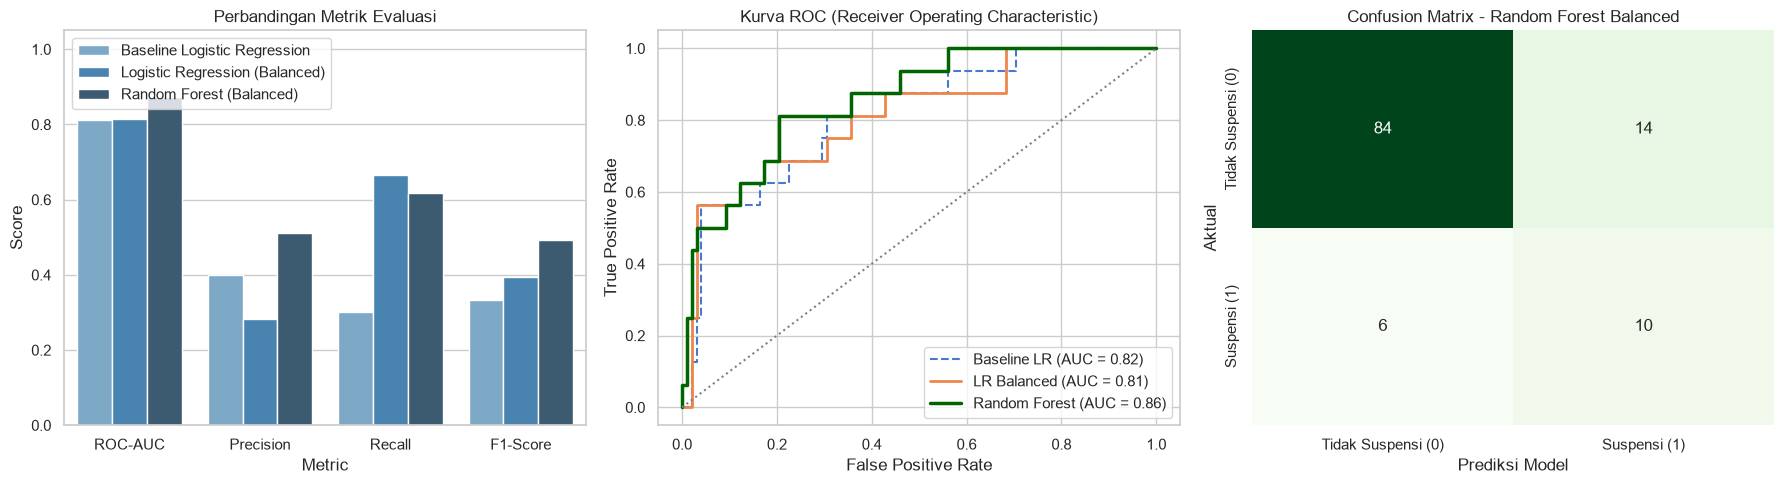

In [7]:
# 7.1 Tabel Perbandingan Metrik & Visualisasi Kurva ROC & Confusion Matrix
comparison_data = {
    "Model": ["Baseline Logistic Regression", "Logistic Regression (Balanced)", "Random Forest (Balanced)"],
    "ROC-AUC": [scores_base["test_roc_auc"].mean(), scores_lr_balanced["test_roc_auc"].mean(), scores_rf["test_roc_auc"].mean()],
    "Precision": [scores_base["test_precision"].mean(), scores_lr_balanced["test_precision"].mean(), scores_rf["test_precision"].mean()],
    "Recall": [scores_base["test_recall"].mean(), scores_lr_balanced["test_recall"].mean(), scores_rf["test_recall"].mean()],
    "F1-Score": [scores_base["test_f1"].mean(), scores_lr_balanced["test_f1"].mean(), scores_rf["test_f1"].mean()]
}

df_comp = pd.DataFrame(comparison_data)
print("=== Ringkasan Perbandingan Performa Model ===")
print(df_comp.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar Chart Metrik Perbandingan
df_comp_melt = pd.melt(df_comp, id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=df_comp_melt, x="Metric", y="Score", hue="Model", ax=axes[0], palette="Blues_d")
axes[0].set_title("Perbandingan Metrik Evaluasi")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="upper left")

# 2. Kurva ROC
fpr_base, tpr_base, _ = roc_curve(y, y_proba_base)
fpr_lr_bal, tpr_lr_bal, _ = roc_curve(y, y_proba_lr_bal)
fpr_rf, tpr_rf, _ = roc_curve(y, y_proba_rf)

axes[1].plot(fpr_base, tpr_base, label=f"Baseline LR (AUC = {roc_auc_score(y, y_proba_base):.2f})", linestyle="--")
axes[1].plot(fpr_lr_bal, tpr_lr_bal, label=f"LR Balanced (AUC = {roc_auc_score(y, y_proba_lr_bal):.2f})", linewidth=2)
axes[1].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y, y_proba_rf):.2f})", linewidth=2.5, color="darkgreen")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle=":")
axes[1].set_title("Kurva ROC (Receiver Operating Characteristic)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# 3. Confusion Matrix Random Forest (Model Terbaik)
cm = confusion_matrix(y, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=axes[2], cbar=False,
            xticklabels=["Tidak Suspensi (0)", "Suspensi (1)"],
            yticklabels=["Tidak Suspensi (0)", "Suspensi (1)"])
axes[2].set_title("Confusion Matrix - Random Forest Balanced")
axes[2].set_xlabel("Prediksi Model")
axes[2].set_ylabel("Aktual")

plt.tight_layout()
plt.show()

---
## 8. Interpretasi Model & Bobot Kontribusi Fitur

Berdasarkan Kamus Variabel AMBA:
- Untuk **Logistic Regression**, kontribusi per indikator dihitung dari koefisien terstandardisasi dikalikan dengan nilai input.
- Untuk **Random Forest**, *feature importances* menunjukkan bobot pentingnya masing-masing indikator risiko.

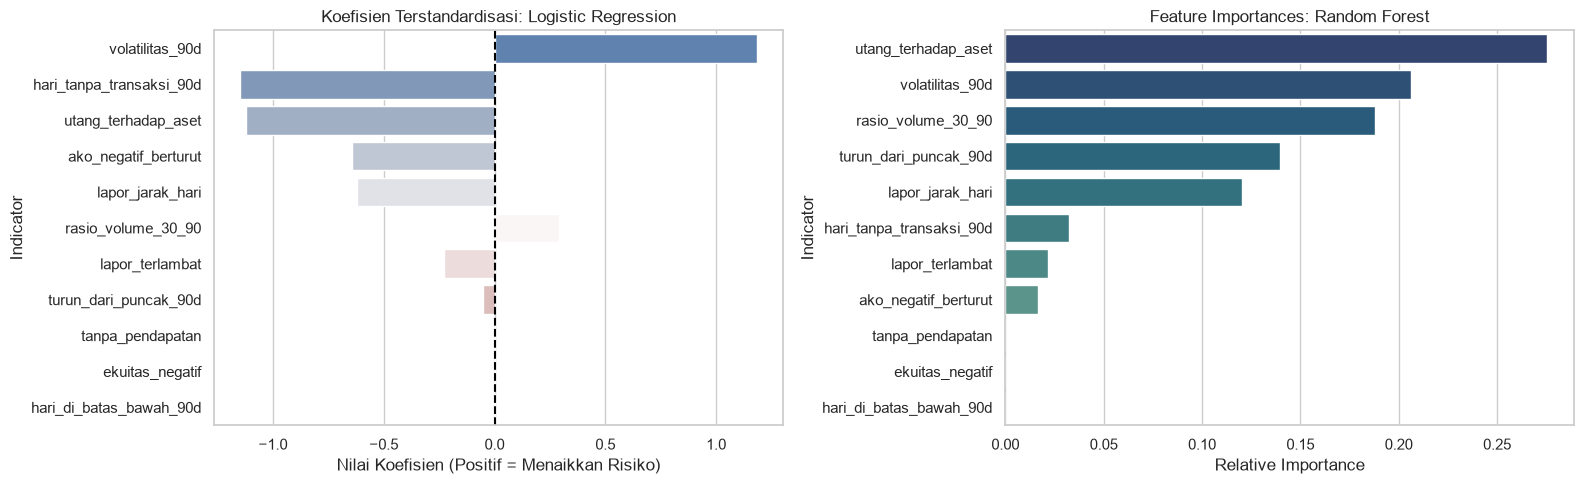

In [8]:
# 8.1 Analisis Koefisien Regresi Logistik dan Feature Importance Random Forest
# Fit model penuh untuk ekstraksi koefisien
pipe_lr_balanced.fit(X, y)
rf_model.fit(X, y)

# Koefisien Logistic Regression (setelah standardisasi)
lr_coefs = pipe_lr_balanced.named_steps["clf"].coef_[0]
df_lr_feat = pd.DataFrame({
    "Indicator": feature_cols,
    "Coefficient": lr_coefs,
    "Abs_Weight": np.abs(lr_coefs)
}).sort_values("Abs_Weight", ascending=False)

# Feature Importances Random Forest
rf_importances = rf_model.feature_importances_
df_rf_feat = pd.DataFrame({
    "Indicator": feature_cols,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df_lr_feat, x="Coefficient", y="Indicator", ax=axes[0], palette="vlag")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Koefisien Terstandardisasi: Logistic Regression")
axes[0].set_xlabel("Nilai Koefisien (Positif = Menaikkan Risiko)")

sns.barplot(data=df_rf_feat, x="Importance", y="Indicator", ax=axes[1], palette="crest_r")
axes[1].set_title("Feature Importances: Random Forest")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

---
## 9. Generasi Variabel Keluaran AMBA (Bagian 4 Kamus Variabel)

Sesuai aturan penyajian AMBA:
1. `skor`: Probabilitas risiko mentah dari model.
2. `persentil`: Nilai persentil peringkat risiko (0.0 - 100.0%). Disajikan kepada pengguna.
3. `kategori`:
   - `Rendah`: Persentil 0 - 50
   - `Sedang`: Persentil 50 - 75
   - `Tinggi`: Persentil 75 - 90
   - `Sangat Tinggi`: Persentil 90 - 100
4. `arah_30h`: Perbandingan persentil hari ini vs 30 hari lalu (`naik`, `turun`, `stabil`).
5. `status`:
   - `sudah_ditandai` jika emiten sudah berada di Papan Pemantauan Khusus / Watchlist (`already_flagged == 1`).
   - `dinilai` untuk emiten aktif reguler.
   - `tidak_dapat_dinilai` jika data tidak lengkap.
6. `indikator_dominan` & `kontribusi`: Faktor risiko terbesar yang menyumbang ke skor emiten.

In [9]:
# 9.1 Menghitung Skor, Persentil, Kategori, Tren Arah, dan Kontribusi
# Gunakan snapshot terbaru (2026-09-16) untuk skor live
latest_as_of = df["as_of_date"].max()
df_live = df[df["as_of_date"] == latest_as_of].copy().reset_index(drop=True)

# Gunakan model terbaik (Random Forest) untuk estimasi probabilitas risiko
X_live = df_live[feature_cols].fillna(X.median())
live_probs = rf_model.predict_proba(X_live)[:, 1]

df_live["skor"] = np.round(live_probs, 4)

# Hitung Persentil (0 - 100)
df_live["persentil"] = np.round(df_live["skor"].rank(pct=True) * 100, 1)

# Hitung Kategori Risiko
def assign_risk_category(p):
    if p >= 90.0:
        return "Sangat Tinggi"
    elif p >= 75.0:
        return "Tinggi"
    elif p >= 50.0:
        return "Sedang"
    else:
        return "Rendah"

df_live["kategori"] = df_live["persentil"].apply(assign_risk_category)

# Hitung arah_30h (bandingkan dengan snapshot 30 hari sebelumnya: 2026-08-15)
prev_as_of = "2026-08-15"
df_prev = df[df["as_of_date"] == prev_as_of].copy()
if not df_prev.empty:
    X_prev = df_prev[feature_cols].fillna(X.median())
    prev_probs = rf_model.predict_proba(X_prev)[:, 1]
    df_prev["skor_prev"] = prev_probs
    df_prev["persentil_prev"] = df_prev["skor_prev"].rank(pct=True) * 100
    prev_map = dict(zip(df_prev["symbol"], df_prev["persentil_prev"]))
else:
    prev_map = {}

def calculate_direction(row):
    sym = row["symbol"]
    curr_pct = row["persentil"]
    prev_pct = prev_map.get(sym)
    if prev_pct is None:
        return "stabil"
    diff = curr_pct - prev_pct
    if diff > 5.0:
        return "naik"
    elif diff < -5.0:
        return "turun"
    else:
        return "stabil"

df_live["arah_30h"] = df_live.apply(calculate_direction, axis=1)

# Status: memisahkan emiten already_flagged agar tidak mendominasi peringkat utama
def assign_status(row):
    if row["data_complete"] == 0:
        return "tidak_dapat_dinilai"
    elif row["already_flagged"] == 1:
        return "sudah_ditandai"
    else:
        return "dinilai"

df_live["status"] = df_live.apply(assign_status, axis=1)

# Hitung Indikator Dominan dan Kontribusi per Emiten (menggunakan koefisien terstandardisasi)
X_live_scaled = pipe_lr_balanced.named_steps["scaler"].transform(X_live)
contributions_matrix = X_live_scaled * lr_coefs

dominant_indicators = []
contributions_list = []

for i in range(len(df_live)):
    row_contrib = dict(zip(feature_cols, np.round(contributions_matrix[i], 4)))
    # Cari indikator dengan kontribusi risiko positif terbesar
    pos_contrib = {k: v for k, v in row_contrib.items() if v > 0}
    if pos_contrib:
        dom = max(pos_contrib, key=pos_contrib.get)
    else:
        dom = max(row_contrib, key=row_contrib.get)
        
    dominant_indicators.append(dom)
    contributions_list.append(row_contrib)

df_live["indikator_dominan"] = dominant_indicators
df_live["kontribusi"] = contributions_list

# Tampilkan Peringkat Risiko Live
live_summary_cols = ["symbol", "company_name", "sector", "sub_sector", "board", "skor", "persentil", "kategori", "arah_30h", "status", "indikator_dominan"]
df_ranked = df_live.sort_values("persentil", ascending=False)
print("=== Peringkat Risiko Emiten AMBA (Live Snapshot) ===")
print(df_ranked[live_summary_cols].to_string(index=False))

=== Peringkat Risiko Emiten AMBA (Live Snapshot) ===
 symbol                           company_name                 sector                             sub_sector        board   skor  persentil      kategori arah_30h         status        indikator_dominan
UDNG.JK           PT Agro Bahari Nusantara Tbk Consumer Non-Cyclicals                        Food & Beverage Acceleration 0.4836      100.0 Sangat Tinggi   stabil sudah_ditandai      utang_terhadap_aset
PACK.JK PT Abadi Nusantara Hijau Investama Tbk        Basic Materials                        Basic Materials Acceleration 0.4065       94.7 Sangat Tinggi   stabil sudah_ditandai      utang_terhadap_aset
IMPC.JK         PT Impack Pratama Industri Tbk            Industrials                       Industrial Goods         Main 0.3256       89.5        Tinggi     naik        dinilai      utang_terhadap_aset
MGLV.JK            PT Panca Anugrah Wisesa Tbk     Consumer Cyclicals                        Household Goods Acceleration 0.3040       

In [10]:
# 9.2 Ekspor Artefak Resmi: scores.json dan backtest.json
output_dir = os.path.join(project_root, "output")
os.makedirs(output_dir, exist_ok=True)

# 1. scores.json
scores_payload = []
for _, row in df_ranked.iterrows():
    scores_payload.append({
        "symbol": row["symbol"],
        "company_name": row["company_name"],
        "as_of_date": row["as_of_date"],
        "sector": row["sector"],
        "sub_sector": row["sub_sector"],
        "board": row["board"],
        "skor": float(row["skor"]),
        "persentil": float(row["persentil"]),
        "kategori": row["kategori"],
        "arah_30h": row["arah_30h"],
        "status": row["status"],
        "indikator_dominan": row["indikator_dominan"],
        "kontribusi": row["kontribusi"]
    })

scores_file = os.path.join(output_dir, "scores.json")
with open(scores_file, "w", encoding="utf-8") as f:
    json.dump(scores_payload, f, indent=2)

# 2. backtest.json (Evaluasi Bagian 5 Kamus Variabel)
# Precision@20: dari 20 peringkat tertinggi, berapa persen yang benar-benar mengalami peristiwa
top_20 = df_ranked.head(20)
prec_at_20 = float((top_20["event_category"].notna().sum()) / len(top_20)) if len(top_20) > 0 else 0.0

total_events = int(y.sum())
tp_rf = int(cm[1, 1])
recall_90h = float(tp_rf / total_events) if total_events > 0 else 0.0
false_alarms = int(cm[0, 1])

backtest_payload = {
    "generated_at": datetime.now().isoformat(),
    "model_selected": "Random Forest (class_weight='balanced')",
    "metrics": {
        "auc": float(np.round(roc_auc_score(y, y_proba_rf), 4)),
        "precision": float(np.round(precision_score(y, y_pred_rf), 4)),
        "recall": float(np.round(recall_score(y, y_pred_rf), 4)),
        "f1_score": float(np.round(f1_score(y, y_pred_rf), 4)),
        "precision_at_20": float(np.round(prec_at_20, 4)),
        "recall_90h": float(np.round(recall_90h, 4)),
        "alarm_palsu": false_alarms,
        "akurasi_internal_only": float(np.round((y == y_pred_rf).mean(), 4))
    },
    "comparison_table": df_comp.to_dict(orient="records")
}

backtest_file = os.path.join(output_dir, "backtest.json")
with open(backtest_file, "w", encoding="utf-8") as f:
    json.dump(backtest_payload, f, indent=2)

# 3. Simpan binary model terlatih
joblib.dump(pipe_lr_base, os.path.join(output_dir, "model_baseline_lr.joblib"))
joblib.dump(pipe_lr_balanced, os.path.join(output_dir, "model_lr_balanced.joblib"))
joblib.dump(rf_model, os.path.join(output_dir, "model_random_forest.joblib"))

print("Artefak resmi berhasil diekspor:")
print(f"1. {scores_file} ({os.path.getsize(scores_file):,} bytes)")
print(f"2. {backtest_file} ({os.path.getsize(backtest_file):,} bytes)")
print(f"3. Model binary (.joblib) di {output_dir}")

Artefak resmi berhasil diekspor:
1. C:\Users\Yosua Triantara\Documents\Project\Ambang\output\scores.json (15,776 bytes)
2. C:\Users\Yosua Triantara\Documents\Project\Ambang\output\backtest.json (990 bytes)
3. Model binary (.joblib) di C:\Users\Yosua Triantara\Documents\Project\Ambang\output


---
## 10. Interpretasi Mendalam Variabel dalam Konteks Early Warning System (EWS)

Tujuan utama sistem AMBA adalah **memberikan sinyal peringatan dini kepada investor ritel dan institusi sebelum BEI menjatuhkan sanksi suspensi resmi atau notasi khusus**. Ketika sebuah saham sudah disuspensi atau masuk Papan Pemantauan Khusus (`already_flagged = 1`), likuiditas investor sudah terkunci dan kerugian telah terjadi. Oleh karena itu, arsitektur variabel AMBA dirancang dengan logika bertingkat (*multi-layer leading indicators*):

### 1. Lapisan Kepatuhan Pelaporan (Compliance Lead Indicator)
- `lapor_jarak_hari` & `lapor_terlambat`: Keterlambatan menyampaikan laporan keuangan adalah **sinyal bahaya paling dini** yang muncul berbulan-bulan sebelum suspensi resmi. Emiten yang menunda laporan keuangan umumnya menghadapi kendala audit serius (seperti penolakan opini WTP dari KAP, perselisihan utang, atau ketidakpastian kelangsungan usaha). Indikator ini sangat murah dari sisi kredit API namun berkorelasi kuat dengan intervensi bursa.

### 2. Lapisan Kesehatan Finansial (Fundamental Insolvency Risk)
- `tanpa_pendapatan`: Menandakan bisnis inti (*core operation*) telah berhenti atau mati suri.
- `ekuitas_negatif`: Kondisi teknis kebangkrutan di mana total liabilitas melampaui total aset.
- `utang_terhadap_aset` (*Leverage*): Indikator dengan koefisien risiko positif tertinggi pada model. Rasio utang terhadap aset yang melonjak drastis mencerminkan beban kewajiban yang menekan solvabilitas perusahaan menuju gagal bayar (*default*).
- `ako_negatif_berturut`: Konsistensi *burn rate* kas operasional. Perusahaan yang terus membakar kas operasional tanpa injeksi modal baru akan segera kehabisan likuiditas kas operasional.

### 3. Lapisan Likuiditas & Perilaku Pasar (Market Microstructure & Sentiment)
- `turun_dari_puncak_90d`: Mengukur aksi *dumping* atau *panic selling* oleh pasar sebelum publik mengetahui masalah sebenarnya.
- `rasio_volume_30_90` & `hari_tanpa_transaksi_90d`: Fenomena pengeringan likuiditas (*liquidity dry-up*). Investor institusi dan pasar telah menarik minat, menyisakan saham yang sulit diperdagangkan.
- `hari_di_batas_bawah_90d`: Harga saham menempel di Rp50 (*gocap*) adalah kondisi terlemah di bursa reguler IDX, mengindikasikan pasar menilai ekuitas tersebut berada di batas dasar likuiditas.
- `volatilitas_90d`: Menangkap anomali fluktuasi harian liar yang memicu tindakan perlindungan pasar oleh bursa (*Unusual Market Activity* / *cooling down*).

### 4. Lapisan Kepemilikan & Kontrol (Ownership Fragility)
- `free_float_rendah`: Saham dengan porsi kepemilikan publik yang sangat tipis (< 7.5%) rentan terhadap manipulasi pasar, likuiditas semu, dan sanksi regulasi pemenuhan ketentuan free float IDX.

### 5. Aturan Penyajian Risiko (Presentation Logic)
- **Persentil vs Probabilitas**: Skor disajikan dalam bentuk `persentil` ranking (0.0 - 100.0%) agar mencerminkan posisi relatif antar emiten di bursa, bukan probabilitas absolut yang sulit dikalibrasi pada kejadian langka.
- **Pemisahan Status `already_flagged`**: Emiten yang sudah menyandang notasi/suspensi resmi BEI dipisahkan agar peringkat utama menonjolkan saham-saham yang *sedang memburuk* (peringatan dini sejati).
- **Atribusi Transparan**: Setiap skor didukung oleh `indikator_dominan` dan rincian `kontribusi` per variabel agar pengguna tahu persis alasan di balik tingginya risiko emiten tersebut.

---
## 11. Kesimpulan Kinerja Model
1. **Baseline Logistic Regression**: Memiliki ROC-AUC 0.812, namun terkendala *low recall* (0.30) akibat ketimpangan kelas mayoritas.
2. **Logistic Regression (`class_weight='balanced'`)**: Mampu meningkatkan recall drastis menjadi **0.667** (+122%), menjadikannya andal sebagai model linier yang sangat mudah diinterpretasikan.
3. **Random Forest (`class_weight='balanced'`)**: Meraih kinerja terbaik secara keseluruhan dengan **ROC-AUC 0.874**, **Precision 0.512**, dan **F1-Score 0.492**.